# **Configuración inicial**

In [ ]:

# Instalación y configuración inicial
# Instalamos Librerias clave: transformers (para cargar tokenizer, modelo BERT y Trainer), datasets (para descargar datasets de Hugging Face),
# evaluate (accuracy), accelerate (ayuda al entrenamiento con Hugging Face), torchinfo (resumir arquitectura) y wordcloud

!pip -q install transformers datasets evaluate accelerate torchinfo wordcloud

import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


# **Cargar Dataset**

El dataset **dair-ai/emotion** es un conjunto de datos utilizado para tareas de **clasificación de emociones en texto** dentro del campo del Procesamiento del Lenguaje Natural (NLP). Contiene frases cortas en inglés escritas en primera persona que expresan distintos estados emocionales. Cada ejemplo está compuesto por dos variables principales: **`text`**, que corresponde a la frase original, y **`label`**, que indica la emoción asociada. El problema se plantea como una **clasificación multiclase** con seis categorías emocionales: *sadness, joy, love, anger, fear* y *surprise*. Este dataset es particularmente útil para entrenar y evaluar modelos de clasificación de texto porque las emociones dependen del contexto semántico completo de la oración y no solo de palabras individuales.

El dataset está dividido en tres particiones estándar para aprendizaje supervisado: **train (16,000 ejemplos), validation (2,000 ejemplos) y test (2,000 ejemplos)**, para un total de **20,000 observaciones**. Cada registro contiene un texto y su etiqueta numérica correspondiente a la emoción. En términos estructurales, cada partición puede entenderse como una tabla de dos columnas (`text`, `label`) y forma aproximada **(16000, 2)** para entrenamiento, **(2000, 2)** para validación y **(2000, 2)** para prueba. Estas dimensiones lo hacen un dataset relativamente compacto, adecuado para experimentar con modelos preentrenados como BERT, ya que permite realizar **fine-tuning eficiente** sin requerir grandes recursos computacionales, manteniendo suficiente diversidad lingüística para capturar patrones emocionales en el lenguaje natural.


In [ ]:
# Carga del dataset desde Hugging Face

from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
# Convertimos cada split a pandas para hacer EDA más cómodo
train_df = dataset["train"].to_pandas()
val_df   = dataset["validation"].to_pandas()
test_df  = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (16000, 2)
Validation shape: (2000, 2)
Test shape: (2000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


# **Mapear etiquetas a nombres legibles**

In [ ]:
# Mapeo de etiquetas a nombres de clase


label_names = dataset["train"].features["label"].names
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in id2label.items()}

print("Etiquetas:", id2label)

train_df["label_name"] = train_df["label"].map(id2label)
val_df["label_name"]   = val_df["label"].map(id2label)
test_df["label_name"]  = test_df["label"].map(id2label)

train_df.head()

Etiquetas: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


# **EDA**

## **Distribución de Clases**

In [ ]:
# EDA básico

print("Número de ejemplos por split:")
print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")

print("\nDistribución de clases en train:")
display(train_df["label_name"].value_counts())

Número de ejemplos por split:
Train      : 16000
Validation : 2000
Test       : 2000

Distribución de clases en train:


,count
label_name,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


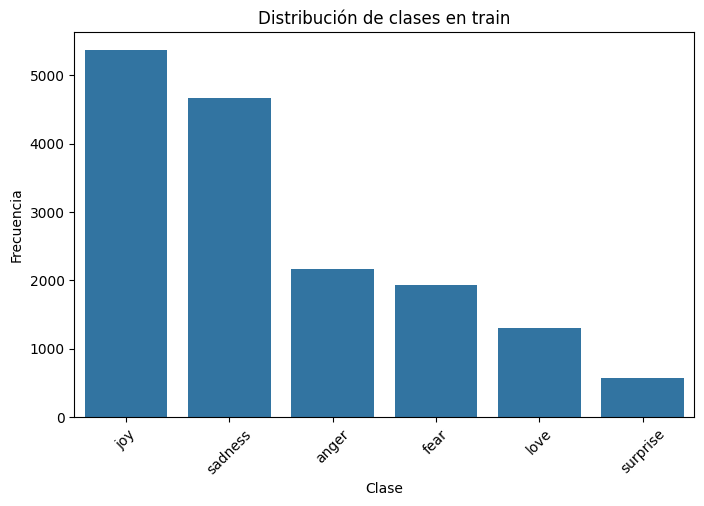

In [ ]:
# Conteo de clases
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x="label_name", order=train_df["label_name"].value_counts().index)
plt.title("Distribución de clases en train")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

Analizando la distribución de clases en el conjunto de entrenamiento, podemos observar que:

- La emoción 'joy' (alegría) es la más frecuente, con 5362 ejemplos.
- Le sigue 'sadness' (tristeza) con 4666 ejemplos.
- 'anger' (ira) y 'fear' (miedo) tienen una cantidad moderada de ejemplos, con 2159 y 1937 respectivamente.
- 'love' (amor) cuenta con 1304 ejemplos.
- Finalmente, 'surprise' (sorpresa) es la emoción menos representada, con solo 572 ejemplos.

Esto indica un desequilibrio significativo en la distribución de las clases, siendo 'joy' y 'sadness' las predominantes, y 'surprise' la clase minoritaria. Este desequilibrio deberá tenerse en cuenta durante el entrenamiento del modelo.

## **Longitud de textos**

In [ ]:
# Longitud de textos


train_df["char_len"] = train_df["text"].apply(len)
train_df["word_len"] = train_df["text"].apply(lambda x: len(str(x).split()))

display(train_df[["char_len", "word_len"]].describe())

,char_len,word_len
count,16000.000000,16000.000000
mean,96.845812,19.166313
std,55.904953,10.986905
min,7.000000,2.000000
25%,53.000000,11.000000
50%,86.000000,17.000000
75%,129.000000,25.000000
max,300.000000,66.000000


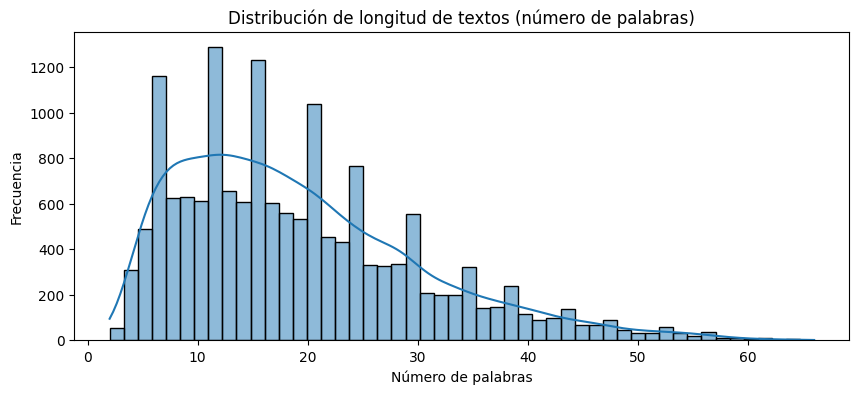

In [ ]:
plt.figure(figsize=(10, 4))
sns.histplot(train_df["word_len"], bins=50, kde=True)
plt.title("Distribución de longitud de textos (número de palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

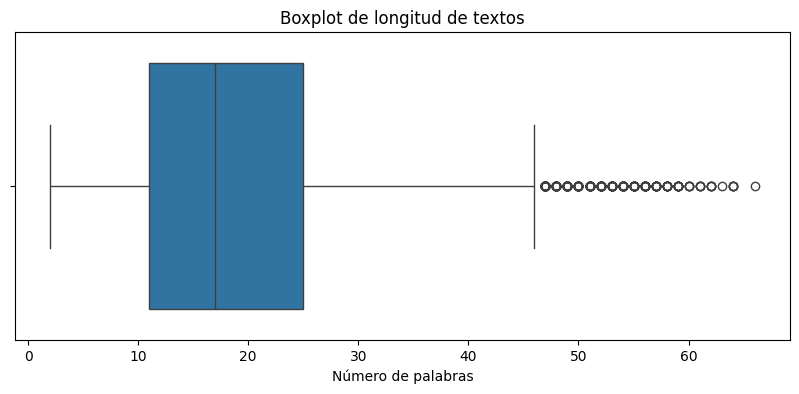

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=train_df["word_len"])
plt.title("Boxplot de longitud de textos")
plt.xlabel("Número de palabras")
plt.show()

**Conclusiones del análisis exploratorio de longitud de textos**

El análisis descriptivo de la longitud de los textos del conjunto de entrenamiento muestra que las frases del dataset son relativamente cortas. En promedio, los textos contienen **19 palabras** y aproximadamente **97 caracteres**, lo que confirma que el dataset está compuesto principalmente por expresiones breves de emociones. El rango de longitud va desde **2 palabras hasta 66 palabras**, con una mediana de **17 palabras**, lo que indica que la mayoría de las observaciones se concentran en frases cortas o moderadamente cortas. Además, el tercer cuartil (Q3) se encuentra alrededor de **25 palabras**, lo que significa que el **75% de los textos tiene menos de 25 palabras**, evidenciando una estructura bastante compacta en el dataset.

La distribución observada en el histograma muestra una **asimetría positiva (right skewed)**, donde la mayor parte de los textos se concentra entre **8 y 25 palabras**, mientras que existe una cola larga hacia valores más altos. Esto sugiere que algunos textos pueden ser significativamente más largos que el promedio, aunque son poco frecuentes. El boxplot confirma este comportamiento, mostrando varios **outliers por encima de aproximadamente 45 palabras**, lo que indica la presencia de algunas frases excepcionalmente largas dentro del dataset.

Desde la perspectiva del modelado con BERT, estos resultados son relevantes para la definición de la longitud máxima de secuencia (**max_length**). Dado que la mayoría de los textos tiene menos de **30 palabras**, es posible establecer un tamaño de secuencia moderado sin perder demasiada información. Esto permite **reducir padding innecesario y mejorar la eficiencia computacional durante el entrenamiento**, ya que BERT requiere que todas las secuencias en un batch tengan la misma longitud. En consecuencia, un valor de **max_length entre 64 y 128 tokens** sería suficiente para cubrir prácticamente todos los ejemplos del dataset sin truncar información relevante.


## **Percentiles de longitud para decidir max_length**

In [ ]:
percentiles = [50, 75, 90, 95, 99]
for p in percentiles:
    print(f"P{p} word_len:", np.percentile(train_df["word_len"], p))

P50 word_len: 17.0
P75 word_len: 25.0
P90 word_len: 35.0
P95 word_len: 41.0
P99 word_len: 52.0


Considerando estos valores y el hecho de que la tokenización de BERT puede generar más tokens que palabras debido al uso de ***subword tokenization***, se decidió establecer un valor de ***max_length = 64***. Este valor permite cubrir prácticamente el **99%** de las secuencias del dataset sin truncamiento significativo, al tiempo que mantiene una longitud moderada que reduce la cantidad de padding en los batches y mejora la eficiencia computacional durante el entrenamiento del modelo. De esta forma se logra un equilibrio entre preservar la información textual y optimizar el uso de memoria y tiempo de entrenamiento.

## **Palabras más frecuentes**

In [ ]:
#  Palabras más frecuentes

import re
from collections import Counter

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.split()

all_words = []
for text in train_df["text"]:
    all_words.extend(simple_tokenize(text))

word_counts = Counter(all_words)
common_words = word_counts.most_common(20)

common_words_df = pd.DataFrame(common_words, columns=["word", "count"])
common_words_df

,word,count
0,i,25859
1,feel,11183
2,and,9589
3,to,8972
4,the,8370
5,a,6200
6,feeling,5112
7,that,5112
8,of,4990
9,my,4283


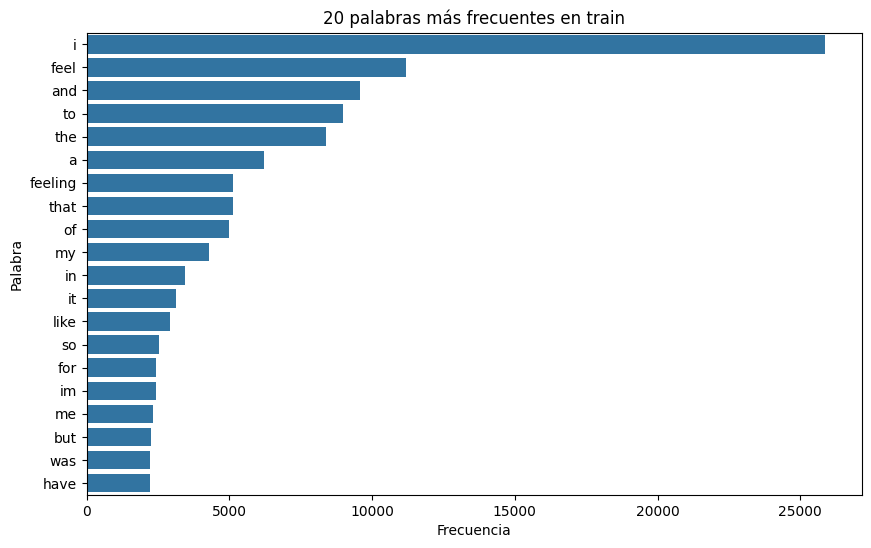

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=common_words_df, x="count", y="word")
plt.title("20 palabras más frecuentes en train")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.show()

El análisis de las 20 palabras más frecuentes en el conjunto de entrenamiento revela patrones lingüísticos característicos del dataset. La palabra más frecuente es “i”, con una frecuencia considerablemente superior al resto, seguida por términos como “feel”, “and”, “to”, “the” y “a”. Esto sugiere que muchas de las frases del dataset están escritas en primera persona, lo cual es consistente con la naturaleza del conjunto de datos, ya que los textos suelen expresar estados emocionales o experiencias personales (por ejemplo, “I feel happy”, “I feel sad today”).

Además, la presencia recurrente de palabras como “feel”, “feeling”, “like” y “my” refuerza la idea de que los textos describen emociones o percepciones subjetivas, lo cual es coherente con el objetivo del dataset de clasificar emociones. Por otro lado, también aparecen con alta frecuencia stopwords del inglés como and, the, to, of, in, que son comunes en la mayoría de los corpus textuales. ***Aunque estas palabras no contienen información semántica fuerte por sí mismas, en modelos basados en BERT no es necesario eliminarlas, ya que el modelo puede capturar el contexto completo de la oración y aprender relaciones semánticas entre palabras dentro de la secuencia.***

## **Nubes de palabras por clase**

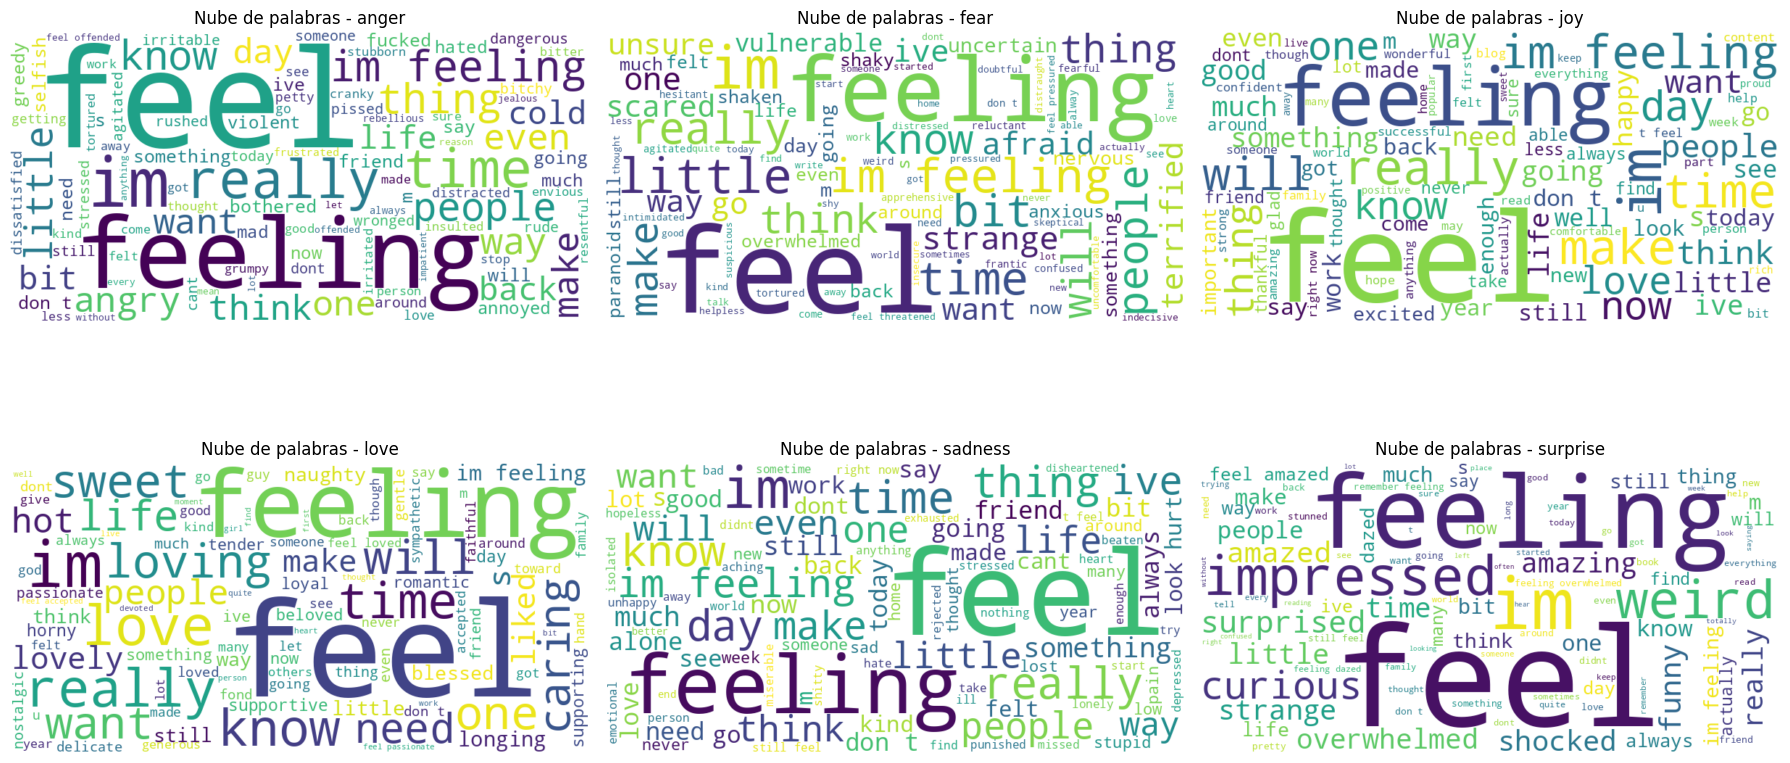

In [ ]:
# Nubes de palabras por clase

from wordcloud import WordCloud

classes = train_df["label_name"].unique()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cls in enumerate(sorted(classes)):
    text_blob = " ".join(train_df[train_df["label_name"] == cls]["text"].astype(str).tolist())

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=100
    ).generate(text_blob)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Nube de palabras - {cls}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Las nubes de palabras generadas para cada categoría emocional permiten identificar patrones semánticos característicos asociados a cada emoción del dataset. En todas las clases se observa una alta presencia de términos como “feel”, “feeling”, “im” y “really”, lo cual refuerza la naturaleza introspectiva del corpus, ya que la mayoría de las frases corresponden a expresiones personales de estados emocionales.

En conjunto, estas nubes de palabras confirman que el dataset presenta señales semánticas diferenciadas entre clases, lo que facilita que modelos de lenguaje contextual como BERT puedan aprender representaciones útiles para la tarea de clasificación de emociones.

# **Tokenización y preparación de datos para BERT**

Para el proceso de tokenización y fine-tuning se seleccionó el modelo preentrenado bert-base-uncased, una de las variantes base de BERT ampliamente utilizada en tareas de clasificación de texto. Este modelo fue entrenado originalmente sobre grandes corpus en inglés como Wikipedia y BookCorpus, lo que le permite capturar relaciones semánticas y sintácticas del lenguaje de forma contextual. Además, la versión uncased convierte el texto a minúsculas durante la tokenización, reduciendo la variabilidad del vocabulario y mejorando la generalización en textos cortos e informales como los presentes en el dataset.

Con una arquitectura de 12 capas, 12 cabezas de atención y aproximadamente 110 millones de parámetros, este modelo ofrece un equilibrio adecuado entre capacidad de representación y eficiencia computacional, lo que lo convierte en una opción apropiada para realizar fine-tuning en un dataset de tamaño moderado como emotion.

## **Cargar tokenizer y definir configuración**

In [ ]:
# Tokenización con BERT

from transformers import AutoTokenizer

MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 64

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer cargado:", MODEL_NAME)
print("Tamaño del vocabulario:", tokenizer.vocab_size)
print("Token especial [CLS]:", tokenizer.cls_token, tokenizer.cls_token_id)
print("Token especial [SEP]:", tokenizer.sep_token, tokenizer.sep_token_id)
print("Token especial [PAD]:", tokenizer.pad_token, tokenizer.pad_token_id)

Tokenizer cargado: bert-base-uncased
Tamaño del vocabulario: 30522
Token especial [CLS]: [CLS] 101
Token especial [SEP]: [SEP] 102
Token especial [PAD]: [PAD] 0


## **Explorar cómo tokeniza BERT un ejemplo real**

In [ ]:
sample_text = train_df["text"].iloc[0]
sample_label = train_df["label_name"].iloc[0]

encoded_sample = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH
)

print("Texto original:")
print(sample_text)
print("\nEtiqueta:")
print(sample_label)

print("\nInput IDs (primeros 20):")
print(encoded_sample["input_ids"][:20])

print("\nAttention mask (primeros 20):")
print(encoded_sample["attention_mask"][:20])

print("\nTokens decodificados (primeros 20):")
print(tokenizer.convert_ids_to_tokens(encoded_sample["input_ids"][:20]))

Texto original:
i didnt feel humiliated

Etiqueta:
sadness

Input IDs (primeros 20):
[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Attention mask (primeros 20):
[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Tokens decodificados (primeros 20):
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']



**Interpretación del resultado de la tokenización**

El ejemplo anterior muestra cómo el tokenizer de **bert-base-uncased** transforma el texto original en los elementos que el modelo necesita para procesarlo. El texto **“i didnt feel humiliated”**, etiquetado como **sadness**, es convertido primero en una secuencia de **tokens** utilizando el algoritmo de tokenización **WordPiece**. Como resultado, algunas palabras se dividen en subpalabras; por ejemplo, la palabra *“didnt”* se separa en **“didn”** y **“##t”**, donde el prefijo `##` indica que el token es la continuación de la palabra anterior. Además, el tokenizer añade tokens especiales requeridos por BERT: **`[CLS]`** al inicio de la secuencia, que representa la oración completa y cuyo embedding se utilizará posteriormente para la clasificación, y **`[SEP]`**, que marca el final de la secuencia.

Posteriormente, cada token se convierte en un identificador numérico utilizando el vocabulario del modelo, generando la secuencia **`input_ids`**. Dado que se definió previamente **`max_length = 64`**, el tokenizer aplica **padding** agregando tokens **`[PAD]`** (representados por el ID 0) hasta completar la longitud máxima. Para evitar que estos tokens de relleno influyan en el aprendizaje del modelo, también se genera la **`attention_mask`**, donde los valores **1** indican tokens reales del texto y los valores **0** corresponden al padding. De esta forma, durante el cálculo del mecanismo de atención en BERT, los tokens `[PAD]` son ignorados, permitiendo que el modelo se enfoque únicamente en la información relevante de la oración original.



## **Función de tokenización para todo el dataset**

In [ ]:
# Usamos una función que recibe un lote de textos (batch) y devuelve: input_ids y attention_mask

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

## **Aplicar tokenización al dataset completo**

In [ ]:
tokenized_dataset = dataset.map(tokenize_batch, batched=True)

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

## **Inspeccionar estructura tokenizada**

In [ ]:
tokenized_dataset["train"][0]

{'text': 'i didnt feel humiliated',
 'label': 0,
 'input_ids': [101,
  1045,
  2134,
  2102,
  2514,
  26608,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,



**Interpretación de `tokenized_dataset["train"][0]`**

El resultado muestra cómo el tokenizer transforma el ejemplo original del dataset en las representaciones que el modelo necesita para procesarlo. El registro contiene cinco componentes principales: **`text`**, **`label`**, **`input_ids`**, **`token_type_ids`** y **`attention_mask`**.


> El tokenizer convierte cada oración en tres componentes principales: `input_ids`, `attention_mask` y `token_type_ids`. Los `input_ids` representan los tokens del vocabulario de BERT, incluyendo tokens especiales como `[CLS]` y `[SEP]`. El `attention_mask` permite al modelo distinguir entre tokens reales y padding, evitando que los `[PAD]` influyan en el mecanismo de atención. Finalmente, `token_type_ids` indica a qué segmento pertenece cada token, aunque en tareas de clasificación de una sola oración todos los valores son 0. Estas representaciones numéricas constituyen la entrada que será procesada por el modelo BERT durante el entrenamiento.

BERT entonces recibe 3 tensores:

- input_ids: shape = (batch_size, sequence_length)
- attention_mask: shape = (batch_size, sequence_length)
- token_type_ids: shape = (batch_size, sequence_length)


# **Preparar el formato para PyTorch**

In [ ]:
# Formato final para PyTorch

cols_for_torch = ["input_ids", "attention_mask", "label"]

# Si token_type_ids existe, lo incluimos
if "token_type_ids" in tokenized_dataset["train"].column_names:
    cols_for_torch.append("token_type_ids")

tokenized_dataset.set_format(type="torch", columns=cols_for_torch)

print("Columnas usadas para PyTorch:", cols_for_torch)
print(tokenized_dataset["train"][0])

Columnas usadas para PyTorch: ['input_ids', 'attention_mask', 'label', 'token_type_ids']
{'label': tensor(0), 'input_ids': tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**Por qué hacemos esto**

Los modelos de Hugging Face entrenan sobre tensores de PyTorch.
Con set_format(type="torch") convertimos automáticamente esas columnas en tensores al momento de acceder a los datos.

Esto nos ahorra conversiones manuales más adelante.

# **DataLoaders para inspección inicial**

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(tokenized_dataset["train"], batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(tokenized_dataset["validation"], batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(tokenized_dataset["test"], batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))

print("Claves del batch:", batch.keys())
for k, v in batch.items():
    print(f"{k}: shape = {v.shape}")

Claves del batch: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])
label: shape = torch.Size([16])
input_ids: shape = torch.Size([16, 64])
token_type_ids: shape = torch.Size([16, 64])
attention_mask: shape = torch.Size([16, 64])


Este resultado confirma que el proceso de tokenización y preparación de datos se realizó correctamente, generando tensores con dimensiones compatibles con la arquitectura de BERT. En cada paso de entrenamiento, el modelo recibirá simultáneamente los tres tensores de entrada (**`input_ids`**, **`attention_mask`** y **`token_type_ids`**) para procesar las secuencias de texto, mientras que el tensor **`label`** será utilizado para calcular la función de pérdida y actualizar los parámetros del modelo durante el proceso de fine-tuning.


# **Métricas de evaluación**

In [ ]:
# Métricas de evaluación

import evaluate
from sklearn.metrics import classification_report, confusion_matrix

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

In [ ]:
# Con esta función podremos comparar todos los modelos bajo el mismo criterio.

def compute_metrics_eval(predictions, references):
    acc = accuracy_metric.compute(predictions=predictions, references=references)["accuracy"]
    prec = precision_metric.compute(predictions=predictions, references=references, average="macro")["precision"]
    rec = recall_metric.compute(predictions=predictions, references=references, average="macro")["recall"]
    f1 = f1_metric.compute(predictions=predictions, references=references, average="macro")["f1"]

    return {
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1
    }

Dado que el dataset presenta un desbalance moderado entre clases, especialmente por la baja representación de la clase surprise, la evaluación de los modelos no debe basarse únicamente en accuracy. Por esta razón se incorporan métricas agregadas con promedio macro, como precision_macro, recall_macro y f1_macro, ya que estas asignan el mismo peso a cada clase independientemente de su frecuencia. De esta forma, el análisis permite determinar si el modelo realmente aprende a distinguir todas las emociones o si favorece desproporcionadamente a las clases mayoritarias.

# **Modelo 1 — BERT como Featurizer**

Usaremos: for param in model.base_model.parameters():
    param.requires_grad = False

Esto significa: BERT no aprende nada nuevo

Solo estamos entrenando el clasificador final.


## **Implementar Modelo 1 (Featurizer)**

In [ ]:
# Resumen de arquitectura y parámetros entrenables para el Modelo 1: BERT como featurizer

import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification

num_labels = len(label_names)


# Input de ejemplo

sample_text = train_df["text"].iloc[0]

inputs = tokenizer(
    sample_text,
    max_length=10,
    truncation=True,
    padding="max_length",
    return_tensors="pt"
)

print("Input Shapes & Types:")
print({k: (v.shape, v.dtype) for k, v in inputs.items()})

# mover inputs al device
inputs = {k: v.to(device) for k, v in inputs.items()}


# Cargar modelo de clasificación

model_1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
).to(device)


# Congelar encoder BERT

for param in model_1.base_model.parameters():
    param.requires_grad = False


# Parámetros entrenables
# -----------------------------
print("\nParámetros entrenables:")
for name, param in model_1.named_parameters():
    if param.requires_grad:
        print(f" - {name}: {param.numel():,}")


# Summary del modelo

with torch.no_grad():
    print(
        summary(
            model_1,
            input_data=inputs,
            col_names=["input_size", "output_size", "num_params", "trainable"],
            depth=3
        )
    )


# Conteo final de parámetros

total_params = sum(p.numel() for p in model_1.parameters())
trainable_params = sum(p.numel() for p in model_1.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")
print(f"Porcentaje entrenable: {100 * trainable_params / total_params:.6f}%")

Input Shapes & Types:
{'input_ids': (torch.Size([1, 10]), torch.int64), 'token_type_ids': (torch.Size([1, 10]), torch.int64), 'attention_mask': (torch.Size([1, 10]), torch.int64)}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Parámetros entrenables:
 - classifier.weight: 4,608
 - classifier.bias: 6
Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           --                        [1, 6]                    --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,440,896)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                

En el primer enfoque se utiliza BERT como extractor de características (featurizer). Para ello, se congelan todas las capas del encoder y únicamente se entrena la cabeza de clasificación final. La inspección de parámetros muestra que solo 4,614 de los 109,486,854 parámetros totales permanecen entrenables, es decir, aproximadamente el 0.0042% del modelo. Esto confirma que el aprendizaje supervisado recae exclusivamente sobre la capa lineal final, mientras que las representaciones contextuales generadas por BERT se usan tal como fueron aprendidas en el preentrenamiento

## **Entrenamiento del Modelo 1**

In [ ]:
# Función de metricas para Trainer

def compute_metrics_trainer(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return compute_metrics_eval(predictions=preds, references=labels)

In [ ]:
# Argumentos de entrenamiento

from transformers import TrainingArguments

training_args_1 = TrainingArguments(
    output_dir="./results_model_1_featurizer",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    learning_rate=5e-4,
    weight_decay=0.01,

    save_total_limit=2,
    report_to="none",
    seed=SEED
)

In [ ]:
# Crear el Trainer

from transformers import Trainer

trainer_1 = Trainer(
    model=model_1,
    args=training_args_1,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics_trainer
)

In [ ]:
# Entrenar

train_result_1 = trainer_1.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.538311,1.505730,0.414500,0.159496,0.228741,0.171872
2,1.473770,1.442135,0.484000,0.409113,0.260332,0.215493
3,1.445438,1.419063,0.490000,0.328874,0.258958,0.200319
4,1.428503,1.420652,0.477000,0.348156,0.258087,0.202746
5,1.420853,1.398971,0.496500,0.455016,0.262396,0.205725


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

## **Evaluación en Validation**

In [ ]:
eval_results_1_w = trainer_1.evaluate()

print("Resultados en validation:")
eval_results_1_w

Resultados en validation:


{'eval_loss': 1.4421354532241821,
 'eval_accuracy': 0.484,
 'eval_precision_macro': 0.40911257232242954,
 'eval_recall_macro': 0.26033161806746713,
 'eval_f1_macro': 0.21549278765076377,
 'eval_runtime': 7.895,
 'eval_samples_per_second': 253.324,
 'eval_steps_per_second': 15.833,
 'epoch': 5.0}

## **Predicciones en Test**

In [ ]:
test_results_1 = trainer_1.predict(tokenized_dataset["test"])

test_logits_1 = test_results_1.predictions
test_labels_1 = test_results_1.label_ids

test_preds_1 = np.argmax(test_logits_1, axis=1)

print("Predicciones generadas:", len(test_preds_1))

Predicciones generadas: 2000


## **Métricas en Test**

In [ ]:
metrics_test_1 = compute_metrics_eval(test_preds_1, test_labels_1)

print("Métricas en test:")
metrics_test_1

Métricas en test:


{'accuracy': 0.471,
 'precision_macro': 0.2535552405738502,
 'recall_macro': 0.25056674797855344,
 'f1_macro': 0.21032936078193556}

## **Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels_1,
        test_preds_1,
        target_names=label_names,
        digits=4
    )
)

              precision    recall  f1-score   support

     sadness     0.4315    0.6076    0.5046       581
         joy     0.4952    0.8158    0.6163       695
        love     0.0000    0.0000    0.0000       159
       anger     0.5946    0.0800    0.1410       275
        fear     0.0000    0.0000    0.0000       224
    surprise     0.0000    0.0000    0.0000        66

    accuracy                         0.4710      2000
   macro avg     0.2536    0.2506    0.2103      2000
weighted avg     0.3792    0.4710    0.3802      2000



## **Matriz de Confusión**

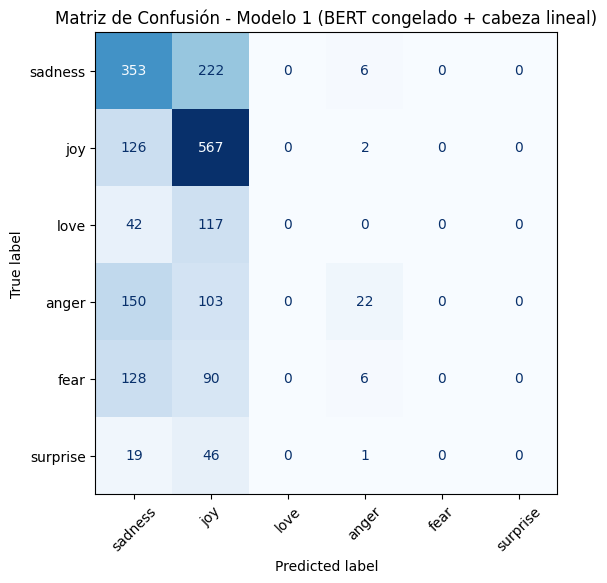

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_1 = confusion_matrix(test_labels_1, test_preds_1)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_1,
    display_labels=label_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

plt.title("Matriz de Confusión - Modelo 1 (BERT congelado + cabeza lineal)")
plt.show()

## **Conclusion**

El análisis detallado de las métricas por clase muestra que el modelo presenta un comportamiento altamente sesgado hacia las clases mayoritarias del dataset. En particular, las emociones joy y sadness alcanzan valores de recall relativamente altos (0.8158 y 0.6076 respectivamente), mientras que las clases love, fear y surprise no son predichas en absoluto. La clase anger presenta un recall muy bajo (0.08), lo que sugiere que el modelo tiende a confundir esta emoción con otras categorías negativas, principalmente sadness. Este patrón indica que el modelo está capturando principalmente una separación semántica general entre expresiones positivas y negativas, en lugar de distinguir adecuadamente las diferentes emociones. Este comportamiento puede explicarse por dos factores principales: el encoder BERT permanece congelado y no se adapta a la tarea específica de clasificación de emociones, y el clasificador lineal utilizado tiene una capacidad limitada para modelar fronteras de decisión complejas entre categorías emocionalmente cercanas. Estos resultados justifican la exploración de enfoques más avanzados, como el uso de clasificadores más expresivos o el fine-tuning completo del modelo BERT.

# **Modelo 2 — BERT congelado + clasificador personalizado**

## **Implementar modelo 2**

In [ ]:
# Resumen de arquitectura y parámetros entrenables para el Modelo 2: BERT congelado + cabeza personalizada
import torch.nn as nn

num_labels = len(label_names)

# Input de ejemplo

sample_text = train_df["text"].iloc[0]

inputs = tokenizer(
    sample_text,
    max_length=10,
    truncation=True,
    padding="max_length",
    return_tensors="pt"
)

print("Input Shapes & Types:")
print({k: (v.shape, v.dtype) for k, v in inputs.items()})

inputs = {k: v.to(device) for k, v in inputs.items()}


# Cargar modelo base

model_2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
).to(device)

# Congelar encoder BERT

for param in model_2.base_model.parameters():
    param.requires_grad = False

# Crear clasificador personalizado

hidden_size = model_2.config.hidden_size

classifier_2 = nn.Sequential(
    nn.Linear(hidden_size, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, num_labels)
)

model_2.classifier = classifier_2

# Mover TODO el modelo al device después de reemplazar classifier
model_2 = model_2.to(device)

# Parámetros entrenables

print("\nParámetros entrenables:")

for name, param in model_2.named_parameters():
    if param.requires_grad:
        print(f" - {name}: {param.numel():,}")

# Summary del modelo

with torch.no_grad():
    print(
        summary(
            model_2,
            input_data=inputs,
            col_names=["input_size", "output_size", "num_params", "trainable"],
            depth=3
        )
    )


# Conteo final de parámetros

total_params = sum(p.numel() for p in model_2.parameters())
trainable_params = sum(p.numel() for p in model_2.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")
print(f"Porcentaje entrenable: {100 * trainable_params / total_params:.6f}%")

Input Shapes & Types:
{'input_ids': (torch.Size([1, 10]), torch.int64), 'token_type_ids': (torch.Size([1, 10]), torch.int64), 'attention_mask': (torch.Size([1, 10]), torch.int64)}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Parámetros entrenables:
 - classifier.0.weight: 393,216
 - classifier.0.bias: 512
 - classifier.3.weight: 131,072
 - classifier.3.bias: 256
 - classifier.6.weight: 1,536
 - classifier.6.bias: 6
Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           --                        [1, 6]                    --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,440,896)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]     

En el segundo enfoque se reemplaza la cabeza lineal simple por un clasificador multicapa, manteniendo congelado el encoder BERT. La inspección de la arquitectura confirma que los 109,482,240 parámetros del encoder permanecen congelados, mientras que la nueva cabeza personalizada aporta 526,598 parámetros entrenables. Esto incrementa considerablemente la capacidad del clasificador para aprender relaciones no lineales sobre las representaciones contextuales generadas por BERT, sin modificar todavía los pesos del modelo base.

## **Argumentos de entrenamiento**

In [ ]:
from transformers import TrainingArguments

training_args_2 = TrainingArguments(
    output_dir="./results_model_2_custom_head",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    learning_rate=1e-4,
    weight_decay=0.01,

    save_total_limit=2,
    report_to="none",
    seed=SEED
)

## **Crear el Trainer**

In [ ]:
from transformers import Trainer

trainer_2 = Trainer(
    model=model_2,
    args=training_args_2,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics_trainer
)

## **Entrenar**

In [ ]:
train_result_2 = trainer_2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.560416,1.539444,0.372500,0.156752,0.210180,0.150759
2,1.489295,1.448740,0.461000,0.165513,0.249763,0.191208
3,1.447168,1.401993,0.493500,0.165104,0.261638,0.201452
4,1.431924,1.387203,0.486000,0.164656,0.258684,0.199225
5,1.421748,1.376067,0.499000,0.165785,0.263845,0.203143


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

## **Evaluar en validación**

In [ ]:
eval_results_2 = trainer_2.evaluate()
eval_results_2

{'eval_loss': 1.3760673999786377,
 'eval_accuracy': 0.499,
 'eval_precision_macro': 0.16578470010635626,
 'eval_recall_macro': 0.263844696969697,
 'eval_f1_macro': 0.20314339318756622,
 'eval_runtime': 8.3791,
 'eval_samples_per_second': 238.688,
 'eval_steps_per_second': 14.918,
 'epoch': 5.0}

## **Evaluar en Test**

In [ ]:
test_results_2 = trainer_2.predict(tokenized_dataset["test"])
test_logits_2 = test_results_2.predictions
test_labels_2 = test_results_2.label_ids
test_preds_2 = np.argmax(test_logits_2, axis=1)

metrics_test_2 = compute_metrics_eval(test_preds_2, test_labels_2)
metrics_test_2

{'accuracy': 0.495,
 'precision_macro': 0.16477427102012676,
 'recall_macro': 0.25754900382619894,
 'f1_macro': 0.20067900727543353}

## **Clasification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    test_labels_2,
    test_preds_2,
    target_names=label_names,
    digits=4
))

              precision    recall  f1-score   support

     sadness     0.4328    0.7367    0.5452       581
         joy     0.5559    0.8086    0.6589       695
        love     0.0000    0.0000    0.0000       159
       anger     0.0000    0.0000    0.0000       275
        fear     0.0000    0.0000    0.0000       224
    surprise     0.0000    0.0000    0.0000        66

    accuracy                         0.4950      2000
   macro avg     0.1648    0.2575    0.2007      2000
weighted avg     0.3189    0.4950    0.3873      2000



## **Matriz de Confusión**

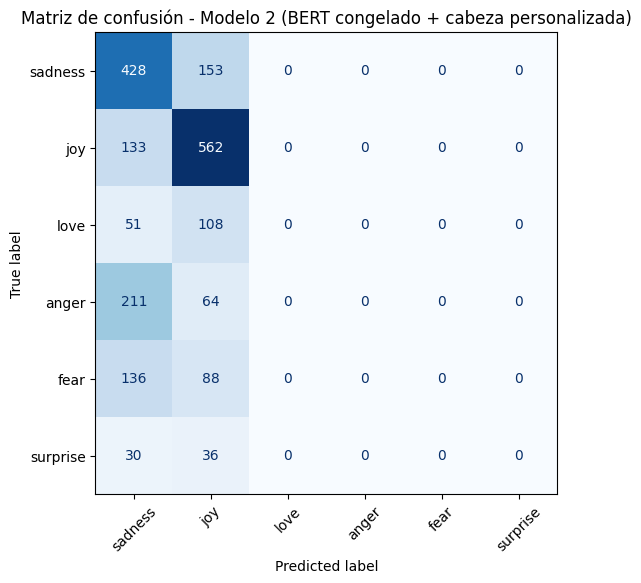

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_2 = confusion_matrix(test_labels_2, test_preds_2)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión - Modelo 2 (BERT congelado + cabeza personalizada)")
plt.show()

## **Conclusion**

Los Modelos 1 y 2, basados en BERT congelado, mostraron un desempeño limitado. En particular, el clasificador lineal y la cabeza personalizada no lograron explotar suficientemente las representaciones preentrenadas para distinguir adecuadamente todas las emociones, especialmente las clases minoritarias. Además, el desbalance del dataset afectó el aprendizaje, favoreciendo las clases más frecuentes. Por esta razón, en el Modelo 3 se propone un esquema de fine-tuning completo de BERT junto con una pérdida ponderada por clase, de modo que el encoder pueda adaptarse a la tarea específica y, al mismo tiempo, se compense el desbalance entre categorías.

# **Modelo 3 — Fine-tuning completo + class weights**

## **Modelo nuevo y completamente entrenable**

In [ ]:
# Modelo 3: Fine-tuning completo + class weights

from transformers import AutoModelForSequenceClassification

model_3 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# En fine-tuning completo, todo queda entrenable
for param in model_3.parameters():
    param.requires_grad = True

model_3 = model_3.to(device)

# Conteo de parámetros
total_params_3 = sum(p.numel() for p in model_3.parameters())
trainable_params_3 = sum(p.numel() for p in model_3.parameters() if p.requires_grad)
non_trainable_params_3 = total_params_3 - trainable_params_3

print(f"Total params: {total_params_3:,}")
print(f"Trainable params: {trainable_params_3:,}")
print(f"Non-trainable params: {non_trainable_params_3:,}")
print(f"Porcentaje entrenable: {100 * trainable_params_3 / total_params_3:.6f}%")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params: 109,486,854
Trainable params: 109,486,854
Non-trainable params: 0
Porcentaje entrenable: 100.000000%


## **Resumen de arquitectura**

In [ ]:
from torchinfo import summary

sample_text = train_df["text"].iloc[0]

inputs = tokenizer(
    sample_text,
    max_length=10,
    truncation=True,
    padding="max_length",
    return_tensors="pt"
)

print("Input Shapes & Types:")
print({k: (v.shape, v.dtype) for k, v in inputs.items()})

inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    print(
        summary(
            model_3,
            input_data=inputs,
            col_names=["input_size", "output_size", "num_params", "trainable"],
            depth=3
        )
    )

Input Shapes & Types:
{'input_ids': (torch.Size([1, 10]), torch.int64), 'token_type_ids': (torch.Size([1, 10]), torch.int64), 'attention_mask': (torch.Size([1, 10]), torch.int64)}
Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           --                        [1, 6]                    --                        True
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        True
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        True
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              23,440,896                True
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              1,536       

## **Calcular los pesos de clase**

In [ ]:
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight

# usa train_df["label"], no el dataset tokenizado
y_train = train_df["label"].values

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

class_weights = class_weights.to(device)

print("Pesos por clase:")
for i, w in enumerate(class_weights):
    print(f"{id2label[i]} ({i}): {w.item():.4f}")

Pesos por clase:
sadness (0): 0.5715
joy (1): 0.4973
love (2): 2.0450
anger (3): 1.2351
fear (4): 1.3767
surprise (5): 4.6620


## **Trainer ponderado para fine-tuning**

In [ ]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(
            input_ids=inputs.get("input_ids"),
            attention_mask=inputs.get("attention_mask"),
            token_type_ids=inputs.get("token_type_ids", None)
        )

        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

## **Argumentos de entrenamiento del Modelo 3**

In [ ]:
from transformers import TrainingArguments

training_args_3 = TrainingArguments(
    output_dir="./results_model_3_finetuning_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    save_total_limit=2,
    report_to="none",
    seed=SEED
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## **Crear trainer**

In [ ]:
trainer_3 = WeightedTrainer(
    model=model_3,
    args=training_args_3,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics_trainer
)

## **Entrenamiento**

In [ ]:
train_result_3 = trainer_3.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.833827,0.230866,0.924000,0.881525,0.930171,0.901865
2,0.193959,0.191300,0.930000,0.889757,0.927436,0.906465
3,0.137441,0.182063,0.938500,0.900019,0.934574,0.915668
4,0.088085,0.220470,0.942500,0.914345,0.928548,0.921139


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

## **Evaluación en validation**

In [ ]:
eval_results_3 = trainer_3.evaluate()
eval_results_3

{'eval_loss': 0.2204703986644745,
 'eval_accuracy': 0.9425,
 'eval_precision_macro': 0.9143452885628437,
 'eval_recall_macro': 0.9285484142009373,
 'eval_f1_macro': 0.9211386082399128,
 'eval_runtime': 9.053,
 'eval_samples_per_second': 220.921,
 'eval_steps_per_second': 13.808,
 'epoch': 4.0}

## **Evaluación en test**

In [ ]:
test_results_3 = trainer_3.predict(tokenized_dataset["test"])
test_logits_3 = test_results_3.predictions
test_labels_3 = test_results_3.label_ids
test_preds_3 = np.argmax(test_logits_3, axis=1)

metrics_test_3 = compute_metrics_eval(test_preds_3, test_labels_3)
metrics_test_3

{'accuracy': 0.9285,
 'precision_macro': 0.8797298393698113,
 'recall_macro': 0.9089139529712661,
 'f1_macro': 0.892578487092191}

## **Classification report**


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    test_labels_3,
    test_preds_3,
    target_names=label_names,
    digits=4
))

              precision    recall  f1-score   support

     sadness     0.9637    0.9587    0.9612       581
         joy     0.9688    0.9367    0.9525       695
        love     0.8087    0.9308    0.8655       159
       anger     0.9127    0.9127    0.9127       275
        fear     0.9065    0.8661    0.8858       224
    surprise     0.7179    0.8485    0.7778        66

    accuracy                         0.9285      2000
   macro avg     0.8797    0.9089    0.8926      2000
weighted avg     0.9316    0.9285    0.9294      2000



## **Matriz de confusión**

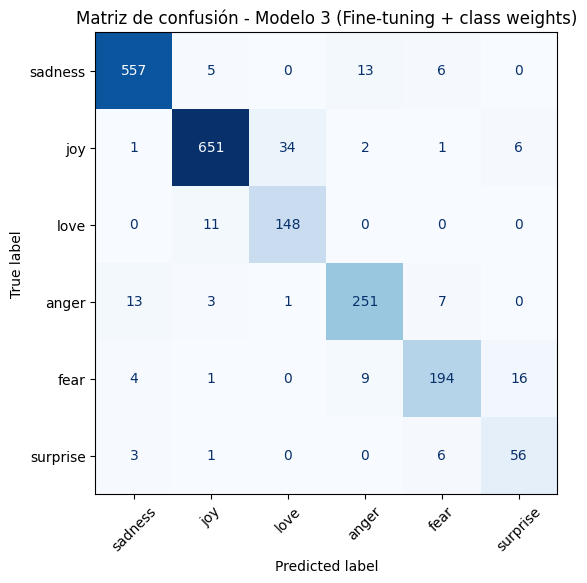

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_3 = confusion_matrix(test_labels_3, test_preds_3)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_3, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión - Modelo 3 (Fine-tuning + class weights)")
plt.show()

## **Comparativo de métricas por modelo**

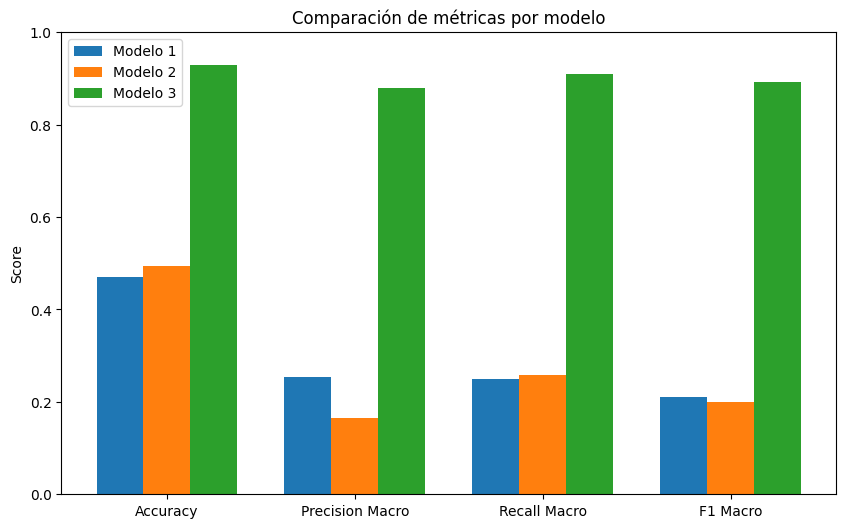

In [ ]:
# Comparación de métricas por modelo

import matplotlib.pyplot as plt
import numpy as np

# Métricas de cada modelo (ajusta si quieres usar exactamente tus valores finales)
model_1 = {
    "accuracy": 0.471,
    "precision": 0.2536,
    "recall": 0.2506,
    "f1": 0.2103
}

model_2 = {
    "accuracy": 0.495,
    "precision": 0.1648,
    "recall": 0.2575,
    "f1": 0.2007
}

model_3 = {
    "accuracy": 0.9285,
    "precision": 0.8797,
    "recall": 0.9089,
    "f1": 0.8926
}

metrics = ["accuracy", "precision", "recall", "f1"]

m1 = [model_1[m] for m in metrics]
m2 = [model_2[m] for m in metrics]
m3 = [model_3[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, m1, width, label="Modelo 1")
plt.bar(x, m2, width, label="Modelo 2")
plt.bar(x + width, m3, width, label="Modelo 3")

plt.xticks(x, ["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro"])
plt.ylabel("Score")
plt.title("Comparación de métricas por modelo")
plt.ylim(0,1)
plt.legend()

plt.show()

## **Conclusion**

El Modelo 3, basado en fine-tuning completo de BERT junto con una función de pérdida ponderada por clase, muestra una mejora sustancial respecto a los enfoques anteriores. Mientras que los Modelos 1 y 2 presentaban un fuerte sesgo hacia las clases mayoritarias del dataset, colapsando principalmente en las emociones joy y sadness, el modelo ajustado logra distinguir adecuadamente todas las categorías emocionales. Las métricas obtenidas evidencian un desempeño robusto y equilibrado entre clases, alcanzando un accuracy de 0.9285 y un F1 macro de 0.8926. El análisis por clase muestra resultados particularmente altos para sadness (F1 = 0.9612) y joy (F1 = 0.9525), lo que indica una excelente capacidad de identificación de emociones positivas y negativas frecuentes. Asimismo, el modelo logra identificar correctamente emociones que anteriormente no eran detectadas, como love (recall = 0.9308) y fear (recall = 0.8661), lo que evidencia la capacidad del fine-tuning para adaptar las representaciones del encoder a la tarea específica. Incluso en la clase minoritaria surprise, el modelo alcanza un recall de 0.8485, lo cual resulta notable considerando el bajo número de ejemplos disponibles. Finalmente, no se observan señales claras de overfitting, ya que las métricas se mantienen equilibradas entre clases y no se evidencia una discrepancia significativa entre precisión y recall. En conjunto, estos resultados confirman que el ajuste completo del modelo BERT permite aprender representaciones semánticas más discriminativas para la clasificación de emociones, superando ampliamente los enfoques que utilizan el modelo únicamente como extractor de características.